# EDA Step 1 - Load the Dataset

In this notebook i will explore two sales dataset that i combined into one.
I also merged in a COVID policy dataset so that I can tell whether each purchase happened during COVID or during a lockdown.

My main goal is to see how shopping behavior changed before, during and after COVID.

First i load the final merged csv dataset and check if there is need for further cleaning.

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Load the final merged dataset
df = pd.read_csv("cleaned_merged_final.csv")
# Standardize categories
category_map = {
    "Electronic": "Electronics",
    "Electronics": "Electronics",
    "Apparel": "Fashion",
    "Fashion": "Fashion",
    "Accessories": "Accessories",
    "Auto & Accessories": "Auto",
    "Furniture": "Home & Furniture",
    "Home & Furniture": "Home & Furniture",
}


# Apply mapping
df["Category"] = df["Category"].replace(category_map)
df = df[df["Category"] != "Auto"]
# Optional: strip whitespace + lowercase + capitalize
df["Category"] = df["Category"].str.strip().str.title()

# Look at the first few rows
df.head()

,Date,Country,Category,ProductName,PaymentMethod,OrderPriority,ReturnStatus,ReturnBinary,UnitPrice,Quantity,...,Net_Revenue,Estimated_Profit,Profit_per_unit,Effective_UnitPrice,Shipping_Burden,Order_Value,stringencyindex,stay_home_requirement,is_covid,is_lockdown
1,2018-01-01,Not Available,Fashion,Running Shoes,credit_card,Critical,Not Available,0,224.0,1.0,...,134.4,120.4,120.40,134.4,0.104167,148.4,0.0,0.0,0,0
2,2018-01-01,Not Available,Fashion,Suits,credit_card,High,Not Available,0,109.0,1.0,...,65.4,62.9,62.90,65.4,0.038226,67.9,0.0,0.0,0,0
3,2018-01-01,Not Available,Home & Furniture,Sofas,money_order,Medium,Not Available,0,67.0,5.0,...,268.0,266.7,53.34,53.6,0.004851,269.3,0.0,0.0,0,0
4,2018-01-01,Not Available,Home & Furniture,Towels,credit_card,High,Not Available,0,228.0,1.0,...,159.6,147.1,147.10,159.6,0.078321,172.1,0.0,0.0,0,0
5,2018-01-01,Not Available,Home & Furniture,Beds,credit_card,Medium,Not Available,0,78.0,2.0,...,78.0,76.0,38.00,39.0,0.025641,80.0,0.0,0.0,0,0


## Step 2 – Basic Checks
Checkin the size of the dataset, column names, datatypes and missing values.

In [41]:
from IPython.display import display

display(df.shape)
display(df.columns)
display(df.dtypes)
display(df.isna().sum())
display(df.describe().T)


(53927, 24)

Index(['Date', 'Country', 'Category', 'ProductName', 'PaymentMethod',
       'OrderPriority', 'ReturnStatus', 'ReturnBinary', 'UnitPrice',
       'Quantity', 'Discount', 'ShippingCost', 'Revenue', 'Discount_Amount',
       'Net_Revenue', 'Estimated_Profit', 'Profit_per_unit',
       'Effective_UnitPrice', 'Shipping_Burden', 'Order_Value',
       'stringencyindex', 'stay_home_requirement', 'is_covid', 'is_lockdown'],
      dtype='object')

Date                      object
Country                   object
Category                  object
ProductName               object
PaymentMethod             object
OrderPriority             object
ReturnStatus              object
ReturnBinary               int64
UnitPrice                float64
Quantity                 float64
Discount                 float64
ShippingCost             float64
Revenue                  float64
Discount_Amount          float64
Net_Revenue              float64
Estimated_Profit         float64
Profit_per_unit          float64
Effective_UnitPrice      float64
Shipping_Burden          float64
Order_Value              float64
stringencyindex          float64
stay_home_requirement    float64
is_covid                   int64
is_lockdown                int64
dtype: object

Date                     0
Country                  0
Category                 0
ProductName              0
PaymentMethod            0
OrderPriority            0
ReturnStatus             0
ReturnBinary             0
UnitPrice                0
Quantity                 0
Discount                 0
ShippingCost             0
Revenue                  0
Discount_Amount          0
Net_Revenue              0
Estimated_Profit         0
Profit_per_unit          0
Effective_UnitPrice      0
Shipping_Burden          0
Order_Value              0
stringencyindex          0
stay_home_requirement    0
is_covid                 0
is_lockdown              0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
ReturnBinary,53927.0,0.086154,0.280593,0.000000,0.000000,0.000000,0.000000,1.000000
UnitPrice,53927.0,63.291694,49.078603,1.000000,29.340000,57.100000,83.050000,250.000000
Quantity,53927.0,22.139429,15.156310,1.000000,8.000000,21.000000,35.000000,49.000000
Discount,53927.0,0.259673,0.145067,0.000000,0.140000,0.260000,0.390000,0.500000
ShippingCost,53927.0,16.217760,7.758830,0.100000,9.970000,15.800000,22.850000,30.000000
Revenue,53927.0,1151.104916,1063.691878,1.010000,289.740000,803.660000,1732.265000,4896.080000
Discount_Amount,53927.0,291.559376,347.888740,0.000000,51.000000,157.662000,399.356950,2364.024600
Net_Revenue,53927.0,859.545541,831.969368,0.717100,207.955200,579.933000,1274.855050,4847.119200
Estimated_Profit,53927.0,843.327780,831.024742,-28.359200,193.052100,561.847600,1258.033050,4834.999200
Profit_per_unit,53927.0,44.004017,34.062252,-28.359200,19.399079,38.949987,59.358764,221.500000


## Create Time Columns
To make the plotting easier i will extract the Year, Month and Day values from the Date column.

In [42]:
# Make sure Date is datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Extract time parts
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.to_period("M").astype(str)
df["Weekday"] = df["Date"].dt.day_name()
df["Day"] = df["Date"].dt.day

# Assign COVID periods
def assign_period(row):
    if row["is_covid"] == 0 and row["Year"] < 2020:
        return "Pre-COVID"
    elif row["is_covid"] == 1 and row["Year"] in [2020, 2021]:
        return "During COVID"
    else:
        return "Post-COVID"

df["Period"] = df.apply(assign_period, axis=1)

df["Period"].value_counts()


Period
Post-COVID      31197
During COVID    16096
Pre-COVID        6634
Name: count, dtype: int64

## Category x Total Quantity
First, I check total amount of products purchased for each category to see the overall pattern.

/var/folders/34/cx2ffffd58d77w9j8w_dybt40000gn/T/ipykernel_2580/3727785483.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales, x="Category", y="Quantity", palette="viridis")


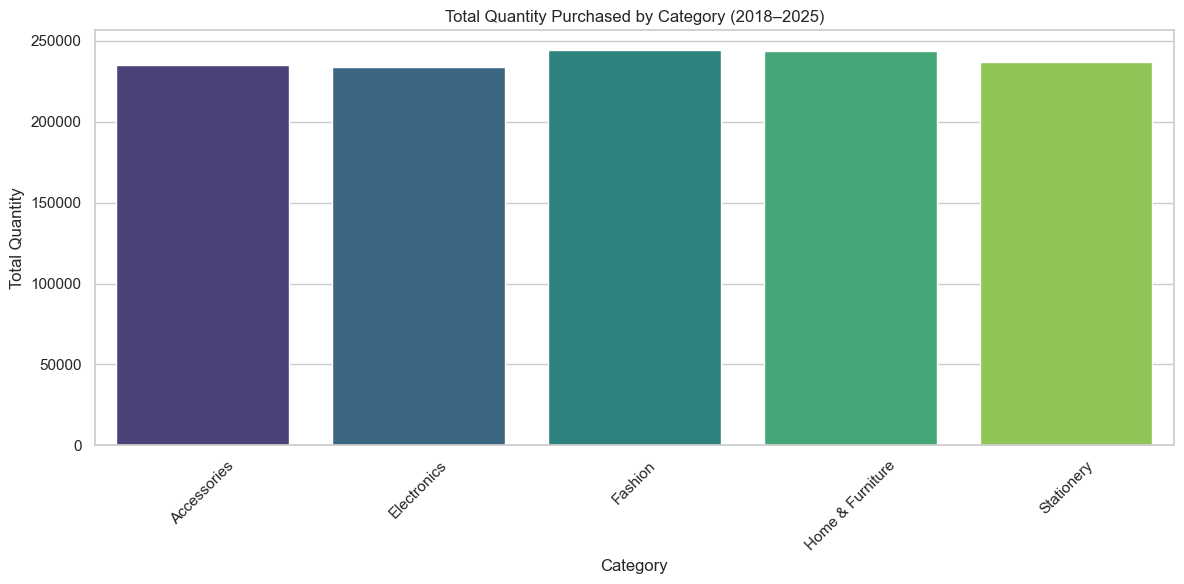

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_sales = df.groupby("Category")["Quantity"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=cat_sales, x="Category", y="Quantity", palette="viridis")

plt.title("Total Quantity Purchased by Category (2018–2025)")
plt.xlabel("Category")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Interpretation
The bar chart shows that amount of purchases made across the categories are fairly, meaning there is no dominant category.

## Heatmap Graphics
I compute and visualize the correlations between key numerical features to see how they relate, including their connection to COVID.

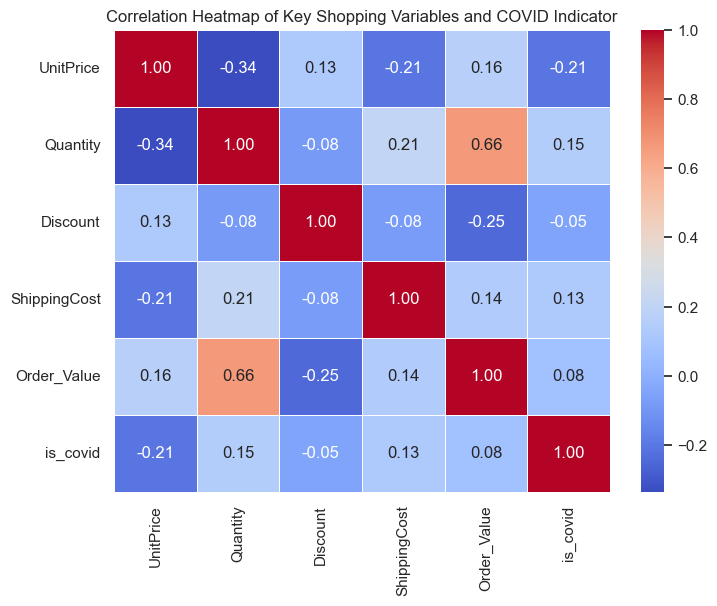

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# List only existing numerical columns
num_cols = [
    "UnitPrice",
    "Quantity",
    "Discount",
    "ShippingCost",
    "Order_Value",
    "is_covid"
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.4)
plt.title("Correlation Heatmap of Key Shopping Variables and COVID Indicator")
plt.show()

Order_value and quantity has a strong positive correlation. While is_covid have weaker relationship. 
This doesn't mean that h0 is true we need to do tests with time series trends and behavioral shift.

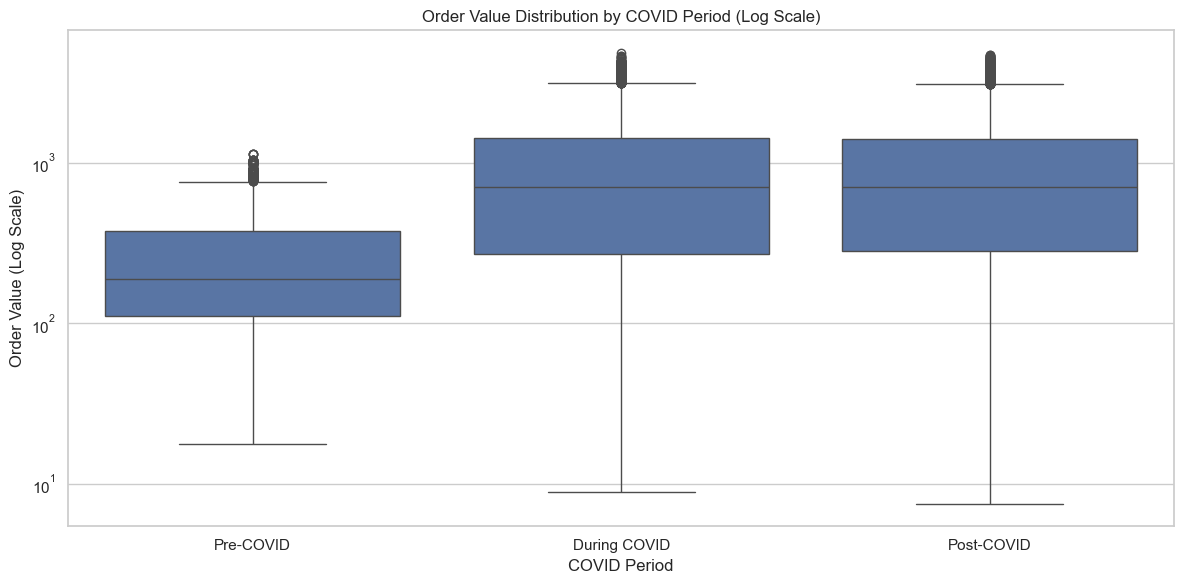

In [61]:
# Force period order
df["Period"] = pd.Categorical(
    df["Period"],
    categories=["Pre-COVID", "During COVID", "Post-COVID"],
    ordered=True
)

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="Period",
    y="Order_Value"
)

plt.yscale("log")
plt.title("Order Value Distribution by COVID Period (Log Scale)")
plt.xlabel("COVID Period")
plt.ylabel("Order Value (Log Scale)")
plt.tight_layout()
plt.show()


We can see from the plot that during and post covid periods the average spending increased.

## Hypothesis Testing
We will try to understand if the evidence is sufficient to reject null hypotheses

In [68]:
from scipy import stats
quantitative_var = 'Estimated_Profit'
categorical_var = 'Category'
alpha = 0.05 # Significance level

# Find the two largest categories by count
top_categories = df[categorical_var].value_counts().nlargest(2).index
cat_a = top_categories[0]
cat_b = top_categories[1]

# Extract the Estimated_Profit data for each of the two groups
group_a_profit = df[df[categorical_var] == cat_a][quantitative_var].values
group_b_profit = df[df[categorical_var] == cat_b][quantitative_var].values

# --- 4. Perform Mann-Whitney U Test (Non-parametric T-test equivalent) ---

# Run the test
u_statistic, p_value = stats.mannwhitneyu(group_a_profit, group_b_profit, alternative='two-sided')

# --- 5. Print Results and Interpretation ---

print(f"--- Mann-Whitney U Test Results ---")
print(f"Comparing Median {quantitative_var} between '{cat_a}' and '{cat_b}'")
print(f"")
print(f"Median {cat_a}: {np.median(group_a_profit):.2f}")
print(f"Median {cat_b}: {np.median(group_b_profit):.2f}")
print(f"")
print(f"Mann-Whitney U Statistic: {u_statistic:.2f}")
print(f"P-value: {p_value:.5f}")
print(f"Significance Level (alpha): {alpha}")
print(f"")

if p_value < alpha:
    print(f"CONCLUSION: Reject the Null Hypothesis.")
    print(f"The P-value ({p_value:.5f}) is less than alpha ({alpha}), indicating a statistically significant difference in the median estimated profit between '{cat_a}' and '{cat_b}'.")
else:
    print(f"CONCLUSION: Fail to Reject the Null Hypothesis.")
    print(f"The P-value ({p_value:.5f}) is greater than alpha ({alpha}), suggesting there is no statistically significant difference in the median estimated profit between '{cat_a}' and '{cat_b}'.")

print("-----------------------------------")

--- Mann-Whitney U Test Results ---
Comparing Median Estimated_Profit between 'Fashion' and 'Home & Furniture'

Median Fashion: 435.90
Median Home & Furniture: 493.90

Mann-Whitney U Statistic: 76317035.50
P-value: 0.00001
Significance Level (alpha): 0.05

CONCLUSION: Reject the Null Hypothesis.
The P-value (0.00001) is less than alpha (0.05), indicating a statistically significant difference in the median estimated profit between 'Fashion' and 'Home & Furniture'.
-----------------------------------
